In [1]:
# EDA ANALYSIS:

In [2]:
 # Импортируем нужные для работы библиотеки:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy import stats

from collections import Counter
from pathlib import Path
from PIL import Image
import imagehash, hashlib

In [3]:
dataset_path = Path("dataset/train")
images_path = dataset_path / "images"
labels_path = dataset_path / "labels"

In [4]:
# функция для определения pHash изображения: 
def get_phash(path):
    return str(imagehash.phash(Image.open(path)))

In [5]:
# Построим единый датафрейм с p-хешом каждого изображения в нём:
common_data = []

for img_path in images_path.glob("*"):

    label_path = labels_path / (img_path.stem + ".txt")

    with Image.open(img_path) as img:
        width, height = img.size

    img_phash = get_phash(img_path)

    common_data.append({
        "image_phash": img_phash,
        "image": str(img_path),
        "label": str(label_path),
        "width": width,
        "height": height
    })

df_pHash = pd.DataFrame(common_data)

In [6]:
df_pHash.head(8)

,image_phash,image,label,width,height
0,b3c8613bccf08cc7,dataset/train/images/114_png_jpg.rf.2f56e1bd1c...,dataset/train/labels/114_png_jpg.rf.2f56e1bd1c...,640,640
1,ee1948649ffa640b,dataset/train/images/image3_png_jpg.rf.06751d9...,dataset/train/labels/image3_png_jpg.rf.06751d9...,640,640
2,c6312af37710deb0,dataset/train/images/illegal87_jpg.rf.8702cf79...,dataset/train/labels/illegal87_jpg.rf.8702cf79...,640,640
3,ec91f2eca5325259,dataset/train/images/2005-mitsubishi-canter-du...,dataset/train/labels/2005-mitsubishi-canter-du...,640,640
4,ad85b64ab13d10dd,dataset/train/images/b9454454-FEXGID1_jpg.rf.3...,dataset/train/labels/b9454454-FEXGID1_jpg.rf.3...,640,640
5,828a2a2a2dbdbd7c,dataset/train/images/frame_027810_PNG.rf.19a07...,dataset/train/labels/frame_027810_PNG.rf.19a07...,640,640
6,83c651d53d3c39e2,dataset/train/images/frame_035940_PNG.rf.3ca60...,dataset/train/labels/frame_035940_PNG.rf.3ca60...,640,640
7,8297554b3c397ae4,dataset/train/images/frame_052980_PNG.rf.63ccb...,dataset/train/labels/frame_052980_PNG.rf.63ccb...,640,640


In [7]:
# Уберём лишние пути в названиях меток:
df_pHash["label"] = df_pHash["label"].str.replace("dataset/train/labels/", "", regex=False)
df_pHash["image"] = df_pHash["image"].str.replace("dataset/train/images/", "", regex=False)

In [8]:
# Посмотрим заново:
df_pHash.head(10)

,image_phash,image,label,width,height
0,b3c8613bccf08cc7,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,640,640
1,ee1948649ffa640b,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...,640,640
2,c6312af37710deb0,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...,640,640
3,ec91f2eca5325259,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...,640,640
4,ad85b64ab13d10dd,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...,640,640
5,828a2a2a2dbdbd7c,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...,640,640
6,83c651d53d3c39e2,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...,640,640
7,8297554b3c397ae4,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...,640,640
8,e6e68c1944ad5b78,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.jpg,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.txt,640,640
9,8a9235333fedc849,screenshot_10001_jpg.rf.b742573602f9158c1b679f...,screenshot_10001_jpg.rf.b742573602f9158c1b679f...,640,640


`pHash` обычно точнее и не так "строго" работает, как стандартный процесс хеширования от hashlib.
прежде, чем искать прямо точные дубликаты, для начала взглянем на общую структуру похожих межжу
собой изображений и вносят ли они хоть какой-то вес в обучении модели собой

In [9]:
df_pHash[['width', 'height']].describe()

,width,height
count,15392.0,15392.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


Итак, видно, что если `max/min=640` && `std=0` && `mean=640` по ширине и высоте, значит абсолютно все картинки
являются одианакового масштаба и размера

In [10]:
df_pHash[["image_phash", "image", "label"]].describe()

,image_phash,image,label
count,15392,15392,15392
unique,12545,15392,15392
top,c1cf3f305a62f08d,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...
freq,111,1,1


In [11]:
# Рассмотрим столбце с p-хешом повнимательнее:
df_pHash["image_phash"].duplicated().sum()

np.int64(2847)

Значит, имеются дубликаты, но это могут быть лишь какие-то похожие сцены или одни и те жн объекты, просто
под разным углом (небольшим наклоном) просмотра

In [12]:
dup_groups_phash = df_pHash.groupby("image_phash").size().sort_values(ascending=False)

dup_phash = dup_groups_phash.index[0] # рассмаотрим самый часто повторяющийся дубликат, для начала
dup_phash_samples = df_pHash[df_pHash["image_phash"] == dup_phash]

In [13]:
dup_phash_samples.head(5)

,image_phash,image,label,width,height
49,c1cf3f305a62f08d,frame_023190_PNG.rf.94f7d2e556dd435d78863a9d95...,frame_023190_PNG.rf.94f7d2e556dd435d78863a9d95...,640,640
440,c1cf3f305a62f08d,frame_011100_PNG.rf.692dde05874998370ccc6ae524...,frame_011100_PNG.rf.692dde05874998370ccc6ae524...,640,640
682,c1cf3f305a62f08d,frame_000330_PNG.rf.671b670a9cc971598bd012138d...,frame_000330_PNG.rf.671b670a9cc971598bd012138d...,640,640
1139,c1cf3f305a62f08d,frame_046320_PNG.rf.f06bf8ff8922091f19b45b91f8...,frame_046320_PNG.rf.f06bf8ff8922091f19b45b91f8...,640,640
1300,c1cf3f305a62f08d,frame_010920_PNG.rf.f555a54d297ed1f291e95c77d9...,frame_010920_PNG.rf.f555a54d297ed1f291e95c77d9...,640,640


In [14]:
# Возьмём 10 первых примеров для рассмотрения:
dup_phash_samples_10 = dup_phash_samples.head(10)
dup_phash_samples_10

,image_phash,image,label,width,height
49,c1cf3f305a62f08d,frame_023190_PNG.rf.94f7d2e556dd435d78863a9d95...,frame_023190_PNG.rf.94f7d2e556dd435d78863a9d95...,640,640
440,c1cf3f305a62f08d,frame_011100_PNG.rf.692dde05874998370ccc6ae524...,frame_011100_PNG.rf.692dde05874998370ccc6ae524...,640,640
682,c1cf3f305a62f08d,frame_000330_PNG.rf.671b670a9cc971598bd012138d...,frame_000330_PNG.rf.671b670a9cc971598bd012138d...,640,640
1139,c1cf3f305a62f08d,frame_046320_PNG.rf.f06bf8ff8922091f19b45b91f8...,frame_046320_PNG.rf.f06bf8ff8922091f19b45b91f8...,640,640
1300,c1cf3f305a62f08d,frame_010920_PNG.rf.f555a54d297ed1f291e95c77d9...,frame_010920_PNG.rf.f555a54d297ed1f291e95c77d9...,640,640
1469,c1cf3f305a62f08d,frame_012180_PNG.rf.1905134fda3201aacba5834438...,frame_012180_PNG.rf.1905134fda3201aacba5834438...,640,640
1488,c1cf3f305a62f08d,frame_023130_PNG.rf.b8e270907b4f09b3d4e362d312...,frame_023130_PNG.rf.b8e270907b4f09b3d4e362d312...,640,640
1497,c1cf3f305a62f08d,frame_002160_PNG.rf.ad85bc507fa6575d6f219b803d...,frame_002160_PNG.rf.ad85bc507fa6575d6f219b803d...,640,640
1498,c1cf3f305a62f08d,frame_015720_PNG.rf.e4e7804bcecb83f44679b41b79...,frame_015720_PNG.rf.e4e7804bcecb83f44679b41b79...,640,640
1751,c1cf3f305a62f08d,frame_015630_PNG.rf.6b28b03316390e16fee9bdd56b...,frame_015630_PNG.rf.6b28b03316390e16fee9bdd56b...,640,640


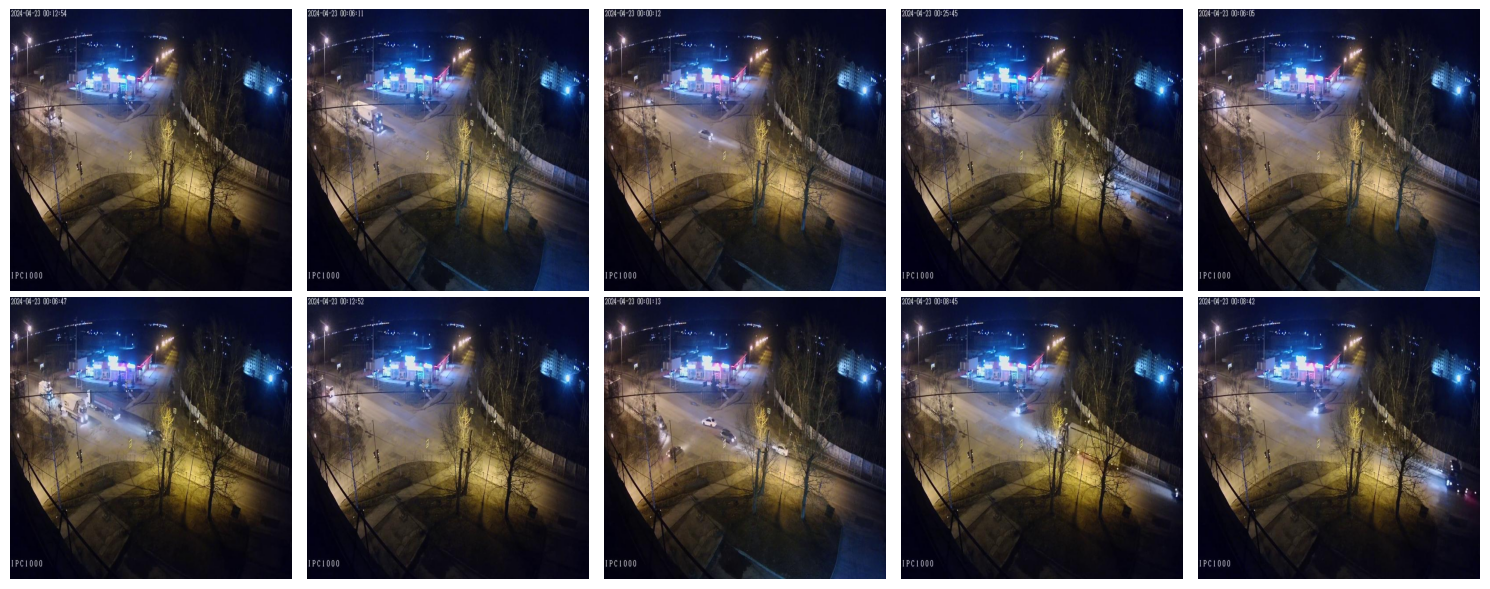

In [15]:
# Попробуем посмотреть на первые 10 изобаржений самого распр. хеша вручную:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, img_path in zip(axes.flatten(), "dataset/train/images/" + dup_phash_samples_10["image"]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Т. Е. мы видим, что `pHash` посчитал абсолютно одинаковыми картинки, в которых всё окружение прямо
статично и практически неотличимо, но основное действие (движение) происходит где-то далеко на фоне 
и потому в общий расчёт p-хеша не попадает и не влияет на него. Изображения, тем не менее, остаются разными.

Имеет ли смысл, в таком случае, проверять оставшиеся картинки? И важны ли они для детектора?
По моему мнению, вполне важны, т. к. они расширяют понимание нейросети по работе в одних и тех же
условиях кадра, при этом с разными объектами на фоне, даже если общая составляющая картинок мало
отличается друг от друга чем-либо. Тем не менее, мы должны ЯВНО удостовериться, что в датасете
нет НИКАКИХ дубликатов, не просто ~похожих по общей составляющей всей сцены, но и если сравнивать 
каждое с каждым по-пиксельно. Для этого нам как раз и пригодится `hashlib`.

In [16]:
# функция для определения pHash изображения: 
def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

In [17]:
hashed_data = []

for img_path in images_path.glob("*"):

    img_hash = get_hash(img_path)

    hashed_data.append({
        "image_hash": img_hash,
        "image": str(img_path)
    })

mini_df_hash = pd.DataFrame(hashed_data)
mini_df_hash["image"] = mini_df_hash["image"].str.replace("dataset/train/images/", "", regex=False)

In [18]:
mini_df_hash.head(10)

,image_hash,image
0,31f46073bdde1d545961cd9b6a6e63a0,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...
1,2df4b7325112cbdd7660c9b42f75d7c2,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...
2,bac4c4f86cacc7fc66981a26f93abf13,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...
3,406d4a3ead77ddab88bdeb0c337202ed,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...
4,b872199bfaca3b5d7b6d93a25c239370,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...
5,2e524208c04c527ffa24e6fec8397f30,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...
6,aaab9011cb70a446ceffae61c7dad247,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...
7,597d6aa61f842a366ebc493ddcdd628e,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...
8,a01556d6bb05ea62d50663f26b5d330b,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.jpg
9,69c4163acf4a1378e702d4323c12fc18,screenshot_10001_jpg.rf.b742573602f9158c1b679f...


In [19]:
df_Hash = df_pHash.copy()

df_Hash = (
    df_Hash
    .merge(mini_df_hash, on="image", how="left")
    .assign(image_phash=lambda x: x["image_hash"])
    .drop(columns=["image_hash"])
    .rename(columns={"image_phash": "image_hash"})
)

df_Hash.head(10)

,image_hash,image,label,width,height
0,31f46073bdde1d545961cd9b6a6e63a0,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,640,640
1,2df4b7325112cbdd7660c9b42f75d7c2,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...,640,640
2,bac4c4f86cacc7fc66981a26f93abf13,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...,640,640
3,406d4a3ead77ddab88bdeb0c337202ed,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...,640,640
4,b872199bfaca3b5d7b6d93a25c239370,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...,640,640
5,2e524208c04c527ffa24e6fec8397f30,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...,640,640
6,aaab9011cb70a446ceffae61c7dad247,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...,640,640
7,597d6aa61f842a366ebc493ddcdd628e,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...,640,640
8,a01556d6bb05ea62d50663f26b5d330b,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.jpg,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.txt,640,640
9,69c4163acf4a1378e702d4323c12fc18,screenshot_10001_jpg.rf.b742573602f9158c1b679f...,screenshot_10001_jpg.rf.b742573602f9158c1b679f...,640,640


Мы аккуратно, следуя названиям, сделали новый датасет с чистыми хешами самих иображений
Теперь можно проверить наш датасет на наличие "чистых" дубликатов 

In [20]:
df_Hash.info()

<class 'pandas.DataFrame'>
RangeIndex: 15392 entries, 0 to 15391
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_hash  15392 non-null  str  
 1   image       15392 non-null  str  
 2   label       15392 non-null  str  
 3   width       15392 non-null  int64
 4   height      15392 non-null  int64
dtypes: int64(2), str(3)
memory usage: 601.4 KB


In [21]:
df_Hash.isna().sum()

image_hash    0
image         0
label         0
width         0
height        0
dtype: int64

In [22]:
# Отлично, значит, в результате переноса информации мы не потеряли никаких данных по хешам самих изображений

In [23]:
df_Hash["image_hash"].duplicated().sum()

np.int64(2)

In [24]:
# Значит, у нас-таки есть 2 ЯВНЫХ дубликата, но нужно взглянуть на них поближе...

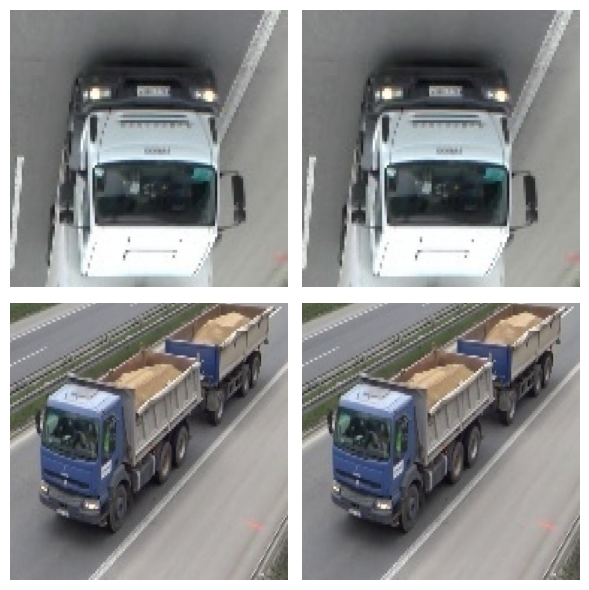

In [25]:
dup_hash_2 = df_Hash[df_Hash["image_hash"].duplicated(keep=False)]
  
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, img_path in zip(axes.flatten(), "dataset/train/images/" + dup_hash_2["image"]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# По всей видимости, это представители классов `construction equipment` (снизу) & `truck` (сверху)...

Итак, с полной уверенностью можно заявить, что дубликаты у нас ЯВНО присутствуют, но всего
их выходит только 2, и на обучение, как мне кажется, совершенно не влияют (в отрц. сторону).
Тем не менее, их стоит удалить, чтобы не учитывать в последующей общей статистике, что будет дальше

In [27]:
# Удалим все дубликаты с их метками

In [28]:
dup_hash_2

,image_hash,image,label,width,height
1105,d9a4ee17bf8fa300d48923b704c06b4b,Image_013578_jpg.rf.ba40fa9c511d585f8302943e2e...,Image_013578_jpg.rf.ba40fa9c511d585f8302943e2e...,640,640
3382,d9a4ee17bf8fa300d48923b704c06b4b,Image_013578_jpg.rf.2ce3e323071bcca95b745cf9c2...,Image_013578_jpg.rf.2ce3e323071bcca95b745cf9c2...,640,640
14357,f96608de23835480052bff4b320321df,Image_013200_jpg.rf.1b7df49ecc2a24042b67a19b9f...,Image_013200_jpg.rf.1b7df49ecc2a24042b67a19b9f...,640,640
14603,f96608de23835480052bff4b320321df,Image_013200_jpg.rf.27af3b183c905853da7583ade7...,Image_013200_jpg.rf.27af3b183c905853da7583ade7...,640,640


In [29]:
# Удалим все дубликаты, оставив сами оригиналы:
df_Hash = df_Hash.drop_duplicates(subset="image_hash", keep="first").reset_index(drop=True)

In [30]:
df_Hash.info()

<class 'pandas.DataFrame'>
RangeIndex: 15390 entries, 0 to 15389
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_hash  15390 non-null  str  
 1   image       15390 non-null  str  
 2   label       15390 non-null  str  
 3   width       15390 non-null  int64
 4   height      15390 non-null  int64
dtypes: int64(2), str(3)
memory usage: 601.3 KB


In [31]:
# Окончательно убедимся в удалении дубликатов:

print(f"Common size of the data: {len(df_Hash)}")
print(f"Count of the duplicates: {df_Hash.duplicated().sum()}")

Common size of the data: 15390
Count of the duplicates: 0


In [32]:
# Теперь, когда дубликатов нет, можно приступать к статист. оценке всего очищенного датасета:

In [33]:
df = (
    df_Hash.copy()
    .drop("image_hash", axis=1)
)

# Посмотрим внимательнее:
df.describe()

,width,height
count,15390.0,15390.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


In [34]:
print(f"Common size of the df: {len(df)}")

Common size of the df: 15390


In [35]:
# Общее число картинок в датасете: 15930

In [36]:
# Теперь узнаем число картинок на каждый класс в отдельности

In [37]:
class_name = {
    0: "bike",
    1: "bus",
    2: "car",
    3: "construction equipment",
    4: "emergency",
    5: "motorbike",
    6: "personal mobility",
    7: "quadbike",
    8: "truck"
}

labels_dir = Path("dataset/train/labels")

class_counter = Counter()

for label_name in df["label"]:
    label_file = labels_dir / label_name

    with open(label_file) as f:
        for line in f:
            cls_id = int(line.split()[0])
            cls_name = class_name[cls_id]
            class_counter[cls_name] += 1

In [38]:
classes_df = pd.DataFrame(
    class_counter.items(),
    columns=["class", "count"]
)

classes_df = classes_df.sort_values("class").reset_index(drop=True)

In [39]:
classes_df

,class,count
0,bike,1599
1,bus,3020
2,car,44092
3,construction equipment,1212
4,emergency,648
5,motorbike,1287
6,personal mobility,10397
7,quadbike,387
8,truck,6975


In [40]:
# Гистограмма классов:

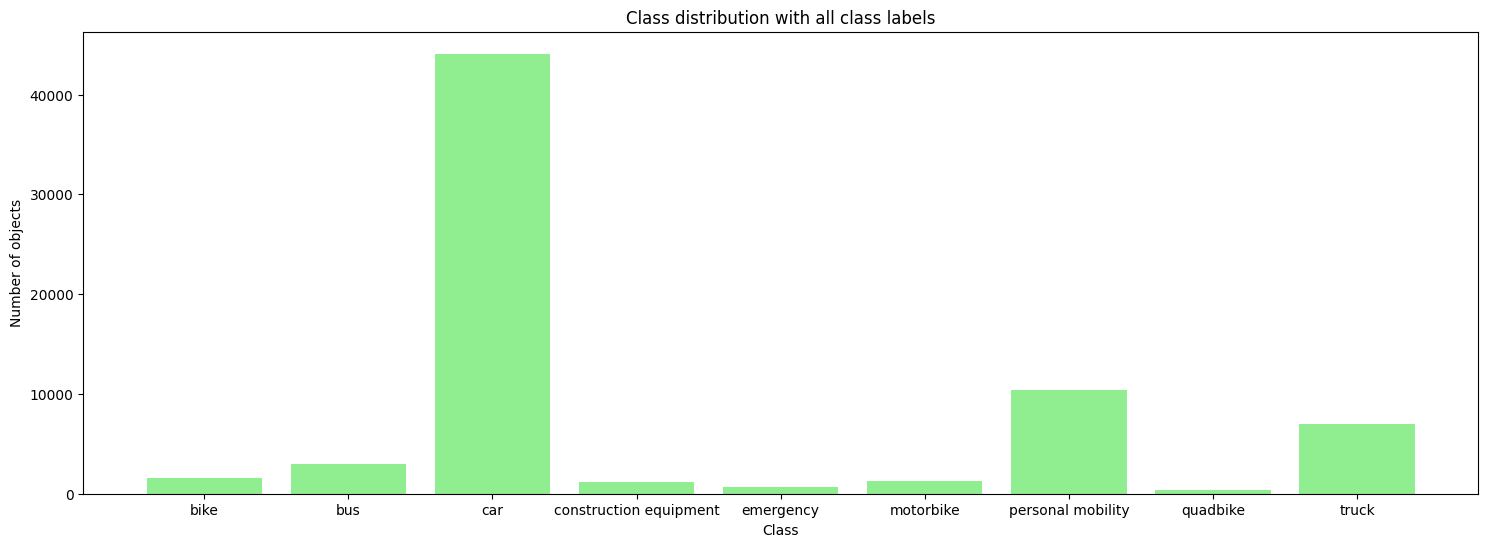

In [41]:
x = classes_df["class"]
y = classes_df["count"]

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x, y, color="lightgreen")

ax.set_xlabel("Class")
ax.set_ylabel("Number of objects")
ax.set_title("Class distribution with all class labels")

ax.set_xticks(x)
ax.set_xticklabels(x, rotation=0)
plt.show()

In [42]:
# Невооружённым глазом можно заметить слишком СЕРЬЁЗНЫЙ дисбаланс классов в датасете

In [43]:
# Теперь посмотрим общую сумму по колонке `count`:
print(f"Common amount: {classes_df['count'].sum()} objects in data")

Common amount: 69617 objects in data


In [44]:
# Класс `car` составляет в общей сложности 44092 объекта из всего числа в 69617 штук. Т. Е. данный класс
# занимает около 2/3 всего датасета (что, учитывая весь масштаб, видится действительно огромным)

Теперь, когда с базовой статистикой мы в целом закончили, можно провести более конкретные исследования. Предлагаю
для начала понять, что у нас по числу объектов на одну картинку - нужно выяснить среднее значение, число изображений
вообще без каких-либо объектов классов и вывести затем общее распределение по всему этому.

In [45]:
# делаем общий numpy-массив всех объектов на каждом отдельном изображении:
objects_per_image = []

for label_path in df["label"]:

    label_file = labels_dir / label_path

    if label_file.exists():
        with open(label_file) as f:
            objects_per_image.append(len(f.readlines()))
    else:
        objects_per_image.append(0)

objects_per_image = np.array(objects_per_image)

In [46]:
# Выведем теперь общую базовую статистику по массиву `objects_per_image`:
mean_objects = objects_per_image.mean()
median_objects = np.median(objects_per_image)
std_objects = objects_per_image.std()

print("Mean:", mean_objects)
print("Median:", median_objects)
print("Std:", std_objects)

Mean: 4.523521767381417
Median: 2.0
Std: 5.237497785082725


In [47]:
# Что-то меня смущает `mean`, надо бы его через бутстрап проверить выборку:
boot_means = []

for _ in range(1000):
    sample = np.random.choice(objects_per_image, size=len(objects_per_image), replace=True)
    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

print("Bootstrap mean:", boot_means.mean())
print("95% CI:", np.percentile(boot_means, [2.5, 97.5]))

Bootstrap mean: 4.524555295646524
95% CI: [4.44516407 4.60353151]


In [48]:
# Раз уж взялись за среднее арифм., нужно бы тогда проверить и медиану:
boot_medians = []

for _ in range(1000):
    sample = np.random.choice(objects_per_image, size=len(objects_per_image), replace=True)
    boot_medians.append(np.median(sample))

boot_medians = np.array(boot_medians)

print("Bootstrap median:", boot_medians.mean())
print("95% CI:", np.percentile(boot_medians, [2.5, 97.5]))

Bootstrap median: 2.0
95% CI: [2. 2.]


In [49]:
# Значит обоим значеням верить можно. Продолжаем анализ

In [50]:
# Определим число картинок, в которых находится довольно много объектов (пусть будет >10):
many_objects = np.sum(objects_per_image > 10)
print("Images with >10 objects:", many_objects)

Images with >10 objects: 1866


In [51]:
# Теперь посмотрим, что у нас по числу "пустых" изображений:
empty_images = np.sum(objects_per_image == 0)
print("Empty images:", empty_images)

Empty images: 1043


In [52]:
# Перед созданием гистограммы распоеделения числа объектоа на картинку было бы также необходимо
# знать "моду" нашего массива:

mode = stats.mode(objects_per_image)
print(f"Mode: {mode[0]} -> Count of repeats: {mode[1]}")

Mode: 1 -> Count of repeats: 5729


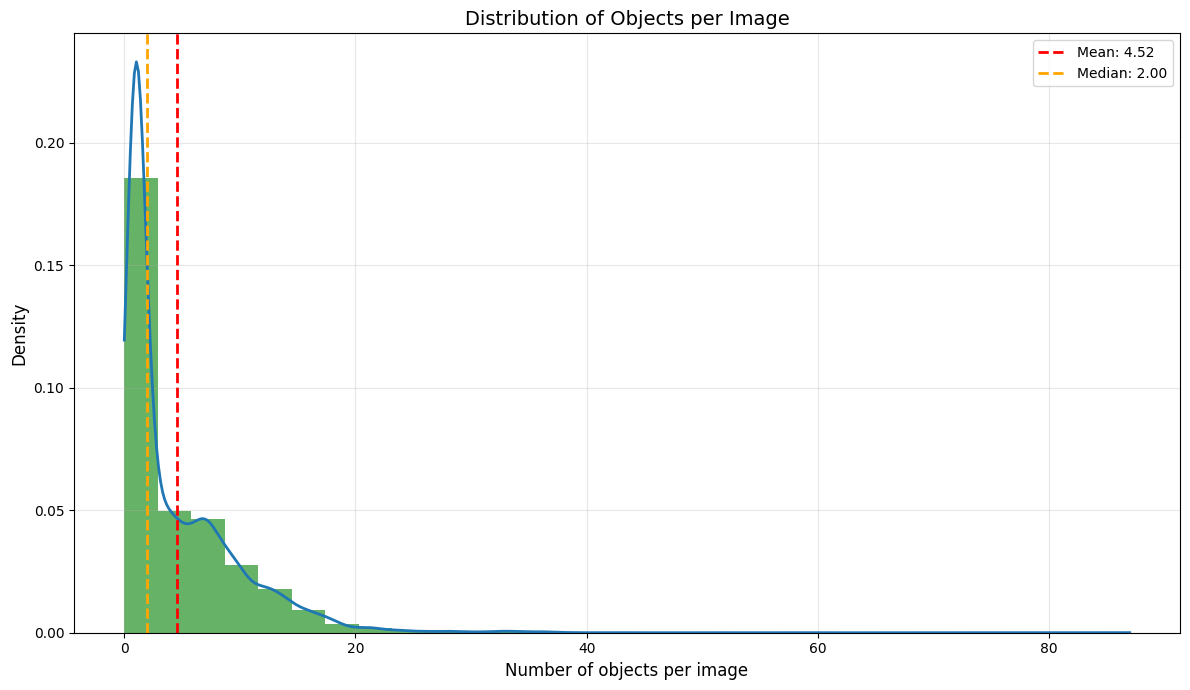

In [53]:
# Выведем теперь общее распределение по всем картинкам, чтобы увидеть общую картину уже целиком:
plt.figure(figsize=(12, 7))

plt.hist(objects_per_image, bins=30, density=True, color='green', alpha=0.6)
kde = gaussian_kde(objects_per_image)

x_vals = np.linspace(objects_per_image.min(), objects_per_image.max(), 500)
plt.plot(x_vals, kde(x_vals), linewidth=2)

# Среднее и медиана:
mean_val = objects_per_image.mean()
median_val = np.median(objects_per_image)

plt.axvline(mean_val, linestyle="--", color='red', linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle="--", color='orange', linewidth=2, label=f"Median: {median_val:.2f}")

# Оформление:
plt.xlabel("Number of objects per image", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of Objects per Image", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Что мы имеем в итоге:

Среднее африм. число объектов на картинку: ~4.5
Среднее медиан. число объектов на картинку: 2.0
Стандартное отклонение: ~5.2
Мода: 1

Число картинок с числом объектов >10: 1866 (около 12%, что не критично, но ощутимо)
Количество картинок без каких-либо объектов: 1043

In [54]:
# Пока что-то трудно сказать, надо больше анализа. Интересно было бы посмотреть, что за объекты
# конкретно какого класса у нас преобладают во всех картинках с 1 bbox'ом.

In [55]:
# Соберём классы только для изображений с 1 объектом:
single_object_classes = []

for label_name in df["label"]:

    label_file = labels_dir / label_name

    if label_file.exists():
        with open(label_file) as f:
            lines = f.readlines()

            if len(lines) == 1:
                class_id = int(lines[0].split()[0])
                single_object_classes.append(class_id)

In [56]:
counter = Counter(single_object_classes)

single_df = pd.DataFrame(
    counter.items(),
    columns=["class", "count"]
).sort_values("count", ascending=False)

single_df["class_name"] = single_df["class"].map(class_name)

total = single_df["count"].sum()
single_df["percentage"] = single_df["count"] / total * 100

In [57]:
# Посмотрим на полученный результат:
single_df

,class,count,class_name,percentage
0,6,3804,personal mobility,66.399023
2,8,788,truck,13.754582
5,0,350,bike,6.109269
3,4,254,emergency,4.433584
1,3,204,construction equipment,3.560831
4,7,145,quadbike,2.530983
6,2,123,car,2.146972
7,1,58,bus,1.012393
8,5,3,motorbike,0.052365


Интересно: т.е. сам по себе класс `personal mobility` хоть и является вторым по численности (~10k), но всё же
слишком уступает классу `car` (~44k), однако при этом вполне себе часто попадается на глаза модели: примерно в
66.4% он встречается среди самого распространённого вида картинок с 1 объектом на них. Стоит проверить также те
картинки, где у нас лежит свыше 1 объекта - какая там ситуация.

In [58]:
# Соберём классы только для изображений с >1 объектов:
multi_object_classes = []

for label_name in df["label"]:
    label_file = labels_dir / label_name

    if label_file.exists():
        with open(label_file) as f:
            lines = f.readlines()

            if len(lines) > 1:
                for line in lines:
                    class_id = int(line.split()[0])
                    multi_object_classes.append(class_id)

In [59]:
counter = Counter(multi_object_classes)

multi_df = pd.DataFrame(
    counter.items(),
    columns=["class", "count"]
).sort_values("count", ascending=False)

multi_df["class_name"] = multi_df["class"].map(class_name)

total = multi_df["count"].sum()
multi_df["percentage"] = multi_df["count"] / total * 100

In [60]:
# Посмотрим на полученный результат:
multi_df

,class,count,class_name,percentage
1,2,43969,car,68.822001
3,6,6593,personal mobility,10.319622
2,8,6187,truck,9.684135
5,1,2962,bus,4.636238
6,5,1284,motorbike,2.009767
4,0,1249,bike,1.954984
0,3,1008,construction equipment,1.577761
8,4,394,emergency,0.616704
7,7,242,quadbike,0.378788


Результат на лицо: теперь свыше половины всех объектов у нас являются объекты класса `car`. А вот класс
`personal mobility` резко падает аж до ~10.32% (но всё же держится на 2-м месте). Делаем вывод: объекты
класса `car` любят преобладать как бы "толпами", тогда как представители класса `personal mobility` по
большей части любят быть по-одиночке. Как это может влиять не модель?

Это уже скорее вносит проблему двойного дисбаланса: с одной стороны, довольно явственно выделяется проблема
обычного дисбаланса по классам, но если вглядываться в самую суть, можно легко увидеть `scene-conditioned class imbalance`:
т. е. класс не распределён равномерно по сценам, а “пристраивается” к типу сцены. Модель может увидеть, условно, скутер
среди группы машин и автоматически решить, что это тоже машина, т.е. привыкла, что такие объекты любят "кучиться". С другой
стороны, увидев одну лишь машину в кадре, модель может подумать о ней как о скутере или прочем представителе класса
`personal mobility`. Это же ведёт к проблеме `context bias`: т.е. многие единичные объекты модель может стать легко распознавать
как скутеры, но на другие классы обращать внимания не станет, т.к. они сравнительно меньше ей попадаются на лицо.

Пока мы не учли, к тому же, ещё и размеры объектов данных классов на картинках, мы уже видим несколько серьёзных проблем,
которые срочно нужно решать.

Цветовую гамму изображений также стоит рассмотреть поближе для выявления каких-либо странных дефектов и там, если они есть.

In [61]:
# Для начала просто посмотрим среднюю яркость по изображениям:

In [62]:
stats = []

images_dir = Path("dataset/train/images")

for img_name in df["image"]:
    img_path = images_dir / img_name
    
    img = np.array(Image.open(img_path).convert("RGB"))
    
    # Средние значения каналов:
    mean_r = img[:, :, 0].mean()
    mean_g = img[:, :, 1].mean()
    mean_b = img[:, :, 2].mean()
    
    # Яркость (простая):
    brightness = img.mean()
    
    # Контраст (std):
    contrast = img.std()
    
    stats.append({
        "image": img_name,
        "mean_r": mean_r,
        "mean_g": mean_g,
        "mean_b": mean_b,
        "brightness": brightness,
        "contrast": contrast
    })

colors_df = pd.DataFrame(stats)

In [63]:
# Общая статистика:
colors_df.describe()

,mean_r,mean_g,mean_b,brightness,contrast
count,15390.000000,15390.000000,15390.000000,15390.000000,15390.000000
mean,118.236473,117.869132,114.898804,117.001470,53.692141
std,27.480555,27.781240,28.715386,27.304946,14.518942
min,5.846279,17.721846,7.180903,16.748054,16.041901
25%,106.206727,103.648052,100.927621,104.063323,43.854372
50%,116.290074,116.622975,112.045156,115.203701,53.403899
75%,129.117863,128.057919,127.434736,126.370183,66.040353
max,246.043508,246.655205,246.652869,246.450527,97.770867


<Axes: >

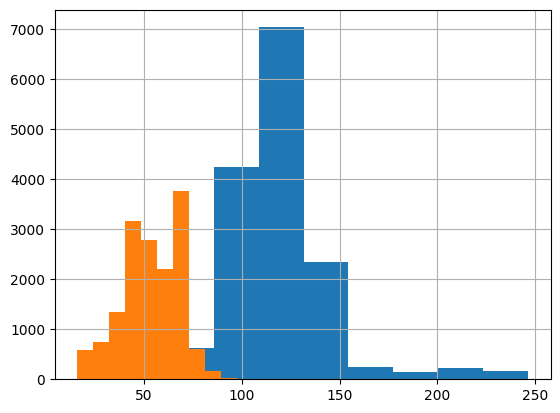

In [64]:
# Сделаем распределения по яркости и контрасту:
colors_df["brightness"].hist()
colors_df["contrast"].hist()

In [65]:
# Средний цвет всего датасета:
colors_df[["mean_r", "mean_g", "mean_b"]].mean()

mean_r    118.236473
mean_g    117.869132
mean_b    114.898804
dtype: float64

Что мы видим? Судя по первичному анализу, сказать можно пока лишь то, что:

1. Средняя яркость изображений составляет ~117 (в диапазоне от ~17 до ~246), что указывает на преобладание 
сцен со средним уровнем освещения.
2. Контраст изображений находится в диапазоне от ~16 до ~97 при среднем значении ~53, что свидетельствует 
об отсутствии значительного числа изображений с экстремально низким или высоким контрастом.
3. Средние значения цветовых каналов (R, G, B) близки друг к другу (~118, ~117, ~115 соответственно), что 
указывает на преобладание нейтральной цветовой гаммы.

В целом, датасет характеризуется:
- умеренной вариативностью освещения,
- отсутствием значительного количества экстремальных условий,
- смещением цветового распределения в сторону нейтральных (серых) тонов.

Уже наталикавет, что такая "серединность" может привести к снижению устойчивости модели к изображениям с 
нетипичными условиями освещения и формированию цветового смещения (color bias), при котором модель начинает 
ассоциировать определённые цветовые характеристики с классами объектов.

Нужно попытаться найти какую-то корреляцию между цветами изображения и числом объектов на нём (при этом учитывая, к каким классам данные объекты будут относиться) - там мы сможем лучше понять, существует ли какая-то взаимосвязь между всем этим либо же вичленить какие-нибудь
прочие аномалии, а может даже и подтвердить предыдущие гипотезы для уверенности. Для этого создадим отдельную таблицу со след. колонками:

In [66]:
labels_dir = Path("dataset/train/labels")
images_dir = Path("dataset/train/images")

rows = []

classes_names = {
    0: "bike",
    1: "bus",
    2: "car",
    3: "construction equipment",
    4: "emergency",
    5: "motorbike",
    6: "personal mobility",
    7: "quadbike",
    8: "truck"
}

for img_name in df["image"]:
    img_path = images_dir / img_name
    label_path = labels_dir / (Path(img_name).stem + ".txt")
    
    # Color features:
    img = np.array(Image.open(img_path).convert("RGB"))
    
    mean_r = img[:, :, 0].mean()
    mean_g = img[:, :, 1].mean()
    mean_b = img[:, :, 2].mean()
    brightness = img.mean()
    
    # Label features:
    class_flags = {name: 0 for name in classes_names.values()}
    num_objects = 0
    
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                class_id = int(line.split()[0])
                class_name = classes_names[class_id]
                
                class_flags[class_name] = 1
                num_objects += 1
    
    row = {
        "image": img_name,
        "mean_r": mean_r,
        "mean_g": mean_g,
        "mean_b": mean_b,
        "brightness": brightness,
        "num_objects": num_objects,
        **class_flags
    }
    
    rows.append(row)

scene_df = pd.DataFrame(rows)

In [67]:
scene_df.head(10)

,image,mean_r,mean_g,mean_b,brightness,num_objects,bike,bus,car,construction equipment,emergency,motorbike,personal mobility,quadbike,truck
0,114_png_jpg.rf.2f56e1bd1c6da6ca37b78ee3d0fd4b9...,233.816912,234.080137,234.339060,234.078703,1,0,0,0,0,0,0,1,0,0
1,image3_png_jpg.rf.06751d96ee0a1a5a35ae5a6ca0c2...,144.832693,151.325278,150.394385,148.850785,29,0,0,1,1,0,0,0,0,1
2,illegal87_jpg.rf.8702cf7960b9ff027ea0088648e70...,127.271765,90.831401,71.211831,96.438333,4,0,0,0,0,0,0,1,0,0
3,2005-mitsubishi-canter-dump-truck-8b_jpg.rf.23...,137.105833,132.310935,114.925039,128.113936,1,0,0,0,1,0,0,0,0,0
4,b9454454-FEXGID1_jpg.rf.3c2b7d318c2e12d5017bd4...,127.163962,106.892483,96.535994,110.197480,1,0,0,0,1,0,0,0,0,0
5,frame_027810_PNG.rf.19a075bf377e9615ef5c77a908...,151.373809,150.255271,148.111973,149.913684,5,1,0,1,0,0,0,0,0,0
6,frame_035940_PNG.rf.3ca6075d3cd4312b17ad23a2fb...,138.257327,140.250481,139.390286,139.299364,4,0,1,1,0,0,0,0,0,0
7,frame_052980_PNG.rf.63ccb629059c04dd299a9a6ca3...,131.283721,133.626362,133.064370,132.658151,8,0,1,1,0,0,0,0,0,0
8,107h_jpg.rf.8031f6b4e3f92e8f4599a2d9bd7cb726.jpg,161.581296,159.318406,152.160767,157.686823,1,0,0,0,0,0,0,1,0,0
9,screenshot_10001_jpg.rf.b742573602f9158c1b679f...,75.423630,76.402402,83.203928,78.343320,1,0,0,0,0,0,0,0,0,1


In [68]:
# Теперь попытаемся найти какую-то корреляцию между яркостью и количеством объектов на картинке:

In [69]:
# Уберём пути к файлам (для расчёта корреляции они не нужны):
corr_df = scene_df.drop(columns=["image"])

In [70]:
# Расчитаем корреляцию:
corr_matrix = corr_df.corr()
corr_matrix

,mean_r,mean_g,mean_b,brightness,num_objects,bike,bus,car,construction equipment,emergency,motorbike,personal mobility,quadbike,truck
mean_r,1.000000,0.949241,0.883079,0.966975,-0.139111,-0.013450,-0.006561,-0.218450,-0.080374,-0.024400,-0.027863,0.288624,-0.051524,-0.220340
mean_g,0.949241,1.000000,0.949800,0.990550,-0.110218,-0.009180,0.017846,-0.179028,-0.129469,-0.047689,-0.028527,0.328841,-0.049874,-0.209006
mean_b,0.883079,0.949800,1.000000,0.968927,-0.077528,0.004283,0.043250,-0.131309,-0.153100,-0.029500,-0.019624,0.301610,-0.052181,-0.176365
brightness,0.966975,0.990550,0.968927,1.000000,-0.111226,-0.006124,0.019013,-0.180032,-0.124542,-0.034701,-0.025902,0.314082,-0.052492,-0.206628
num_objects,-0.139111,-0.110218,-0.077528,-0.111226,1.000000,0.114515,0.423642,0.671967,0.116062,0.072602,0.211070,-0.234473,-0.048595,0.364402
bike,-0.013450,-0.009180,0.004283,-0.006124,0.114515,1.000000,0.001148,0.132742,-0.042658,-0.024329,0.193270,-0.208459,-0.034424,-0.120727
bus,-0.006561,0.017846,0.043250,0.019013,0.423642,0.001148,1.000000,0.387137,-0.070753,-0.017120,0.118316,-0.242096,-0.043661,-0.035621
car,-0.218450,-0.179028,-0.131309,-0.180032,0.671967,0.132742,0.387137,1.000000,0.096471,0.021688,0.141752,-0.464787,-0.091891,0.422329
construction equipment,-0.080374,-0.129469,-0.153100,-0.124542,0.116062,-0.042658,-0.070753,0.096471,1.000000,-0.026954,-0.012139,-0.167308,-0.030752,-0.012254
emergency,-0.024400,-0.047689,-0.029500,-0.034701,0.072602,-0.024329,-0.017120,0.021688,-0.026954,1.000000,0.033978,-0.099894,-0.020386,-0.046040


In [71]:
# Выведем тепловую карту корреляции (для более красивого и наглядного представления):

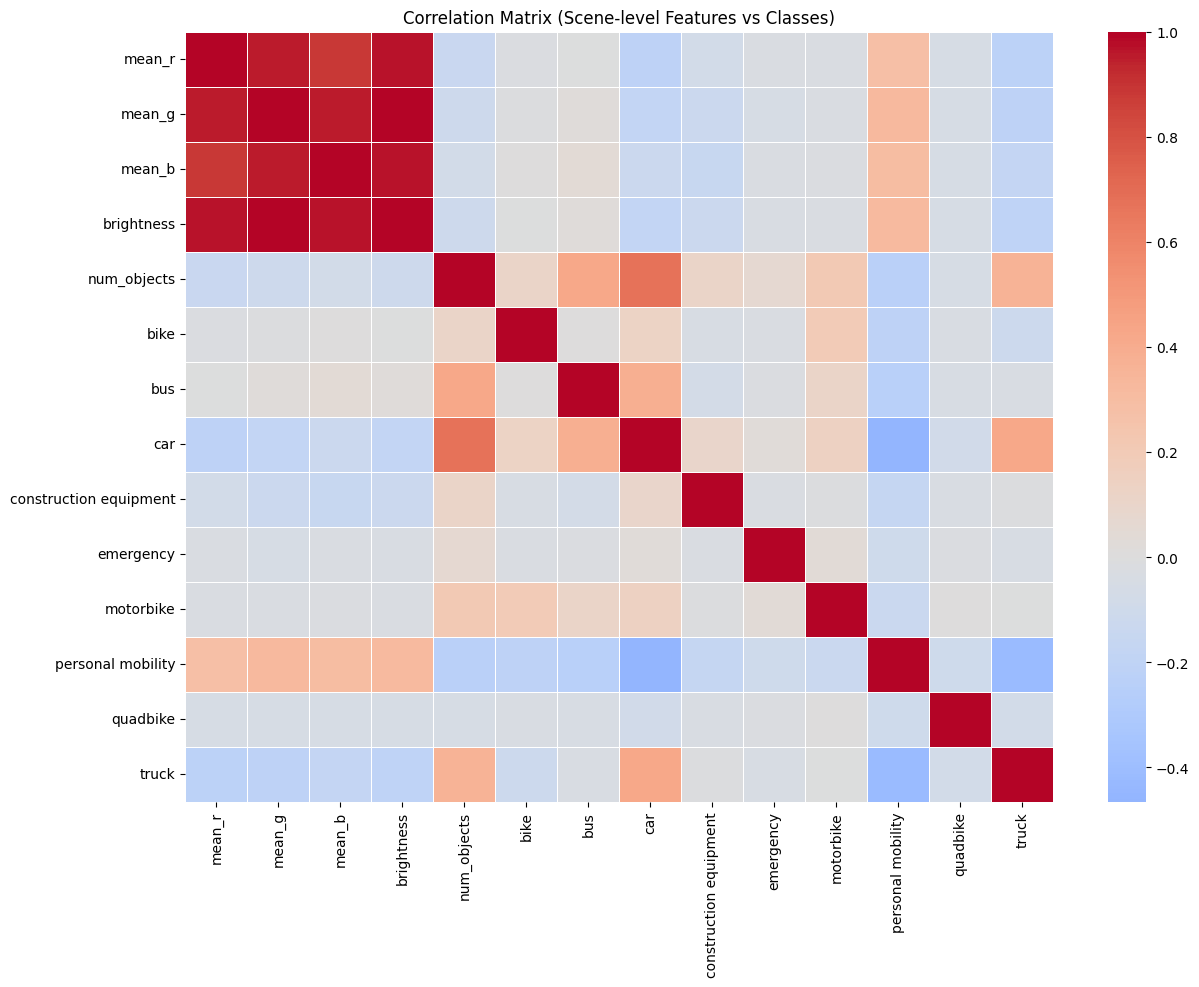

In [72]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=False
)

plt.title("Correlation Matrix (Scene-level Features vs Classes)")
plt.show()

In [73]:
# Итоговые выводы:

В ходе анализа корреляций между признаками сцены и классами объектов были выявлены следующие закономерности:

1) Количество объектов на изображении сильно коррелирует с наличием класса `car` (≈0.67), что подтверждает наличие scene-conditioned дисбаланса.
2) Класс `personal mobility`, напротив, чаще встречается в сценах с малым числом объектов (отрицательная корреляция ≈ -0.23).
   Наблюдается умеренная зависимость классов от яркости сцены:
   - `personal mobility` чаще встречается в более светлых сценах (≈0.31),
   - `car` и `truck` - в более тёмных или нейтральных.
3) Между классами `car` и `personal mobility` наблюдается сильная отрицательная корреляция (≈ -0.46), что указывает на различие типов сцен, в которых они встречаются.

Данные результаты подтверждают наличие контекстных смещений (context bias), при которых распределение классов зависит от характеристик сцены, а не только от визуальных признаков объектов.

In [74]:
# ...